In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing import image
import os
import pandas as pd
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

Memory Growth Enabled


In [3]:
IMG_SIZE = (224, 224) # Resolusi default untuk EfficientNetB0
BATCH_SIZE = 32

train_dir = 'chili_dataset_split/train'
val_dir = 'chili_dataset_split/val'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 9600 files belonging to 6 classes.


I0000 00:00:1777221212.514852   77493 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1399 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 1200 files belonging to 6 classes.


In [4]:
# Load base model tanpa top layer
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False # Freeze bobot awal agar tidak berubah di awal training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.2), # Mengurangi overfitting
    layers.Dense(6, activation='softmax') # 6 kelas sesuai folder kamu
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/20


2026-04-26 23:34:06.555432: I external/local_xla/xla/service/service.cc:163] XLA service 0x794b680152f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-26 23:34:06.555488: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2026-04-26 23:34:07.277970: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-26 23:34:11.160153: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-26 23:34:17.419311: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 406.01MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-26 23:34:23.782872: E externa

300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7991 - loss: 0.5810

2026-04-26 23:35:53.100609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 23:35:53.255480: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 23:35:53.830780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 23:35:53.975742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 23:35:54.129857: E external/local_xla/xla/stream_

300/300 ━━━━━━━━━━━━━━━━━━━━ 133s 274ms/step - accuracy: 0.9080 - loss: 0.2795 - val_accuracy: 0.9900 - val_loss: 0.0870
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 55s 182ms/step - accuracy: 0.9737 - loss: 0.0800 - val_accuracy: 0.9933 - val_loss: 0.0272
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 188ms/step - accuracy: 0.9802 - loss: 0.0588 - val_accuracy: 0.9950 - val_loss: 0.0188
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 56s 186ms/step - accuracy: 0.9871 - loss: 0.0417 - val_accuracy: 0.9942 - val_loss: 0.0185
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 191ms/step - accuracy: 0.9877 - loss: 0.0418 - val_accuracy: 0.9950 - val_loss: 0.0147
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 55s 184ms/step - accuracy: 0.9871 - loss: 0.0411 - val_accuracy: 0.9958 - val_loss: 0.0167
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 207ms/step - accuracy: 0.9901 - loss: 0.0331 - val_accuracy: 0.9942 - val_loss: 0.0171
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/step - accuracy: 0.9895 - loss: 0.0321 - va

In [9]:
# Pastikan path-nya sesuai dengan lokasi datasetmu
test_dir = 'chili_dataset_split/test' 

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False # Penting: Jangan di-shuffle agar urutan label dan prediksi cocok
)

Found 1200 files belonging to 6 classes.


In [10]:
y_true = []
y_pred = []

# Iterasi melalui test dataset
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-04-27 00:20:16.872566: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


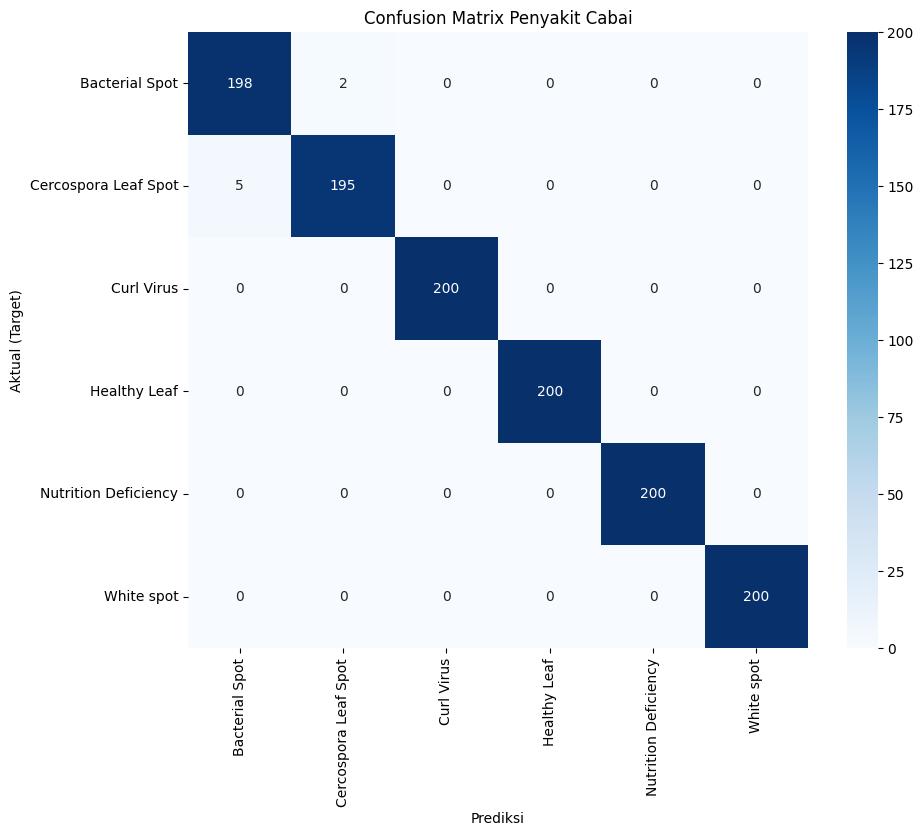

                      precision    recall  f1-score   support

      Bacterial Spot       0.98      0.99      0.98       200
Cercospora Leaf Spot       0.99      0.97      0.98       200
          Curl Virus       1.00      1.00      1.00       200
        Healthy Leaf       1.00      1.00      1.00       200
Nutrition Deficiency       1.00      1.00      1.00       200
          White spot       1.00      1.00      1.00       200

            accuracy                           0.99      1200
           macro avg       0.99      0.99      0.99      1200
        weighted avg       0.99      0.99      0.99      1200



In [11]:
# Ambil nama kelas dari dataset
class_names = train_ds.class_names

# Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual (Target)')
plt.title('Confusion Matrix Penyakit Cabai')
plt.show()

# Print laporan lengkap (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred, target_names=class_names))

In [12]:
model.save('model_chili_efficientnetb0.h5')
# Atau format terbaru
model.save('model_chili_efficientnetb0.keras')

In [13]:
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.9942 - loss: 0.0190
Test Loss: 0.019000329077243805
Test Accuracy: 0.9941666722297668



--- Distribusi Skor Confidence ---
Bacterial Spot: 0.61%
Cercospora Leaf Spot: 0.33%
Curl Virus: 92.51%
Healthy Leaf: 6.37%
Nutrition Deficiency: 0.04%
White spot: 0.14%
----------------------------------
Hasil Akhir: Curl Virus (Valid)


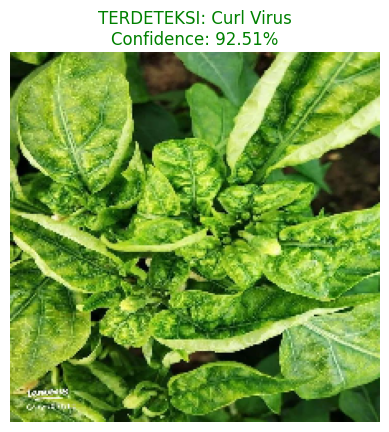

In [31]:
def predict_chili(image_path, threshold=70.0):
    # 1. Load dan Preprocess gambar
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    # 2. Prediksi (Output berupa array probabilitas untuk tiap kelas)
    predictions = model.predict(img_array, verbose=0)
    scores = predictions[0] 

    # 3. Tampilkan list skor tiap penyakit (untuk cek manual)
    print("\n--- Distribusi Skor Confidence ---")
    for i in range(len(class_names)):
        print(f"{class_names[i]}: {scores[i]*100:.2f}%")
    print("----------------------------------")

    # 4. Ambil indeks dengan skor TERTINGGI (Pemenangnya)
    highest_idx = np.argmax(scores)
    highest_score = scores[highest_idx] * 100
    hasil_prediksi = class_names[highest_idx]

    # 5. Logika Threshold & Tampilan
    plt.imshow(img)
    
    # Cek apakah skor tertinggi lolos batas minimal (threshold)
    if highest_score >= threshold:
        status = f"TERDETEKSI: {hasil_prediksi}"
        color = 'green'
        print(f"Hasil Akhir: {hasil_prediksi} (Valid)")
    else:
        status = f"TIDAK YAKIN ({hasil_prediksi}?)"
        color = 'red'
        print(f"Hasil Akhir: Skor tertinggi ({highest_score:.2f}%) di bawah threshold {threshold}%.")

    plt.title(f"{status}\nConfidence: {highest_score:.2f}%", color=color)
    plt.axis('off')
    plt.show()

# Panggil fungsinya
predict_chili('oUsAGBfi6gqSySyQnICS2sENAVEWiyeAB5B4CX~tplv-sdweummd6v-text-logo-v1_QGF5dTA3NjEx_q75.jpeg', threshold=55.0)